## Linear Classifier in TensorFlow 
Using Low Level API in Eager Execution mode

### Load tensorflow

In [0]:
import tensorflow as tf
tf.reset_default_graph()

In [0]:
#Enable Eager Execution if using tensflow version < 2.0
#From tensorflow v2.0 onwards, Eager Execution will be enabled by default


### Collect Data

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [0]:
import pandas as pd
import numpy as np

In [0]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/prices.csv')

### Check all columns in the dataset

In [5]:
df.head(5)

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


### Drop columns `date` and  `symbol`

In [6]:
df = df.drop(["date","symbol"],axis=1)
df.head(5)

,open,close,low,high,volume
0,123.430000,125.839996,122.309998,126.250000,2163600.0
1,125.239998,119.980003,119.940002,125.540001,2386400.0
2,116.379997,114.949997,114.930000,119.739998,2489500.0
3,115.480003,116.620003,113.500000,117.440002,2006300.0
4,117.010002,114.970001,114.089996,117.330002,1408600.0


In [7]:
df.columns

Index([u'open', u'close', u'low', u'high', u'volume'], dtype='object')

volume is the target variable

### Consider only first 1000 rows in the dataset for building feature set and target set
Target 'Volume' has very high values. Divide 'Volume' by 1000,000

In [8]:
data = df[:1000]
data.shape

(1000, 5)

In [9]:
data["volume"] = data["volume"].apply(lambda x: x/1000000)
data["volume"].head(5)

/usr/local/lib/python2.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


0    2.1636
1    2.3864
2    2.4895
3    2.0063
4    1.4086
Name: volume, dtype: float64

### Divide the data into train and test sets

In [10]:
from sklearn.model_selection import train_test_split
X = data.drop("volume",axis=1)
y = data["volume"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=20)
print("Dataset Size: X_train: {}, X_test: {}, y_train {}, y_test: {}".format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))

Dataset Size: X_train: (700, 4), X_test: (300, 4), y_train (700,), y_test: (300,)


#### Convert Training and Test Data to numpy float32 arrays


In [0]:
X_train = np.float32(X_train)
X_test = np.float32(X_test)
y_train = np.float32(y_train)
y_test = np.float32(y_test)

### Normalize the data
You can use Normalizer from sklearn.preprocessing

In [0]:
#Normalize the data

#from sklearn.preprocessing import Normalizer
#X_train = Normalizer().fit(X_train)
#X_test = Normalizer().fit(X_test)

from sklearn.preprocessing import normalize
#x_n = tf.nn.l2_normalize(x,1)
x_train_n = normalize(np.vstack([X_train]), norm='l2', axis=1)
x_test_n = normalize(np.vstack([X_test]), norm='l2', axis=1)

In [13]:
x_train_n

array([[0.5003461 , 0.49821252, 0.49752814, 0.50388867],
       [0.5008902 , 0.49895075, 0.4978279 , 0.5023193 ],
       [0.49721962, 0.50323385, 0.4956507 , 0.50384396],
       ...,
       [0.4963037 , 0.50399053, 0.49479976, 0.50482607],
       [0.5046707 , 0.49542698, 0.4933188 , 0.5064545 ],
       [0.49880284, 0.50020677, 0.49599496, 0.50495344]], dtype=float32)

In [14]:
x_test_n

array([[0.49107265, 0.50744176, 0.49107265, 0.5100962 ],
       [0.49367395, 0.50323606, 0.49367395, 0.5092402 ],
       [0.49567625, 0.5016968 , 0.49540743, 0.5071261 ],
       ...,
       [0.5013367 , 0.49904796, 0.49188313, 0.50760585],
       [0.50212824, 0.4989633 , 0.49610338, 0.50277656],
       [0.50003415, 0.49999183, 0.49592337, 0.50401783]], dtype=float32)

## Building the Model in tensorflow

1.Define Weights and Bias, use tf.zeros to initialize weights and Bias

In [0]:
#Input features
x = tf.placeholder(shape=[None,4],dtype=tf.float32, name='Features')
W = tf.Variable(tf.zeros(shape=[4,1]), name="Weights")
b = tf.Variable(tf.zeros(shape=[1]),name="Bias")

#Normalize the data
#x_n = tf.nn.l2_normalize(x,1)

#
y_ = tf.placeholder(shape=[None],dtype=tf.float32, name='Output')

In [16]:
b.get_shape()

TensorShape([Dimension(1)])

In [17]:
W.get_shape()

TensorShape([Dimension(4), Dimension(1)])

2.Define a function to calculate prediction

In [0]:
def predict(x,w,b):
    return tf.add(tf.matmul(x,w),b)
  
#yPred = tf.add(tf.matmul(x_train_n,W),b,name='output')

In [19]:
yPred = predict(x_train_n, W, b)
yPred.get_shape()

TensorShape([Dimension(700), Dimension(1)])

3.Loss (Cost) Function [Mean square error]

In [20]:
loss = tf.reduce_mean(tf.square(yPred-y_),name='Loss')
loss

<tf.Tensor 'Loss:0' shape=() dtype=float32>

4.Function to train the Model

1.   Record all the mathematical steps to calculate Loss
2.   Calculate Gradients of Loss w.r.t weights and bias
3.   Update Weights and Bias based on gradients and learning rate to minimize loss

MSE a cross-entropy or mean squared error loss function under stochastic gradient descent, minimizes 
the sum of distance of each point to the regression line.
The target of MSE loss function is to minimize the residual sum of squares.
It is the sum, over all the data points, of the square of the difference between the predicted and actual target variables, divided by the number of data points. 
(referred from wiki and a few other pages)

rmse calculation internally  will be similar to  as below

    differences = predictions - targets
    differences_squared = differences ** 2
    mean_of_differences_squared = differences_squared.mean()
    rmse_val = square root of (mean_of_differences_squared) 
 

for i = 0 to number of training examples:
Calculate the gradient of the cost function for the i-th training example with respect to every weight and bias. Now you have a vector full of gradients for each weight and a variable containing the gradient of the bias.
Add the gradients of the weights calculated to a separate accumulator vector which after you’re done iterating over each training example, should contain the sum of the gradients of each weight over the several iterations.
Like the weights, add the gradient of the bias to an accumulator variable.
Now, AFTER iterating over all the training examples perform the following:
Divide the accumulator variables of the weights and the bias by the number of training examples. This will give us the average gradients for all weights and the average gradient for the bias. We will call these the updated accumulators(UAs)
Then, using the formula shown below, update all weights and the bias. In place of dJ/dTheta-j you will use the UA(updated accumulator) for the weights and the UA for the bias. Doing the same for the bias.

This is  just one GD iteration.

Repeat this process from start to finish for some number of iterations. Which means for 1 iteration of GD, you iterate over all the training examples, compute the gradients, then update the weights and biases. You then do this for some number of GD iterations.
(https://hackernoon.com)


In [0]:
train_op = tf.train.GradientDescentOptimizer(0.03).minimize(loss)

## Train the model for 100 epochs 
1. Observe the training loss at every iteration
2. Observe Train loss at every 5th iteration

In [22]:
#Lets start graph Execution
sess = tf.Session()

# variables need to be initialized before we can use them
sess.run(tf.global_variables_initializer())

#how many times data need to be shown to model
training_epochs = 100

for epoch in range(training_epochs):
            
    #Calculate train_op and loss
    t, train_loss = sess.run([train_op,loss],feed_dict={x:x_train_n, y_:y_train})
    
    if epoch % 5 == 0:
        print ('Training loss at step: ', epoch, ' is ', train_loss)

('Training loss at step: ', 0, ' is ', 235.25508)
('Training loss at step: ', 5, ' is ', 215.1746)
('Training loss at step: ', 10, ' is ', 209.58195)
('Training loss at step: ', 15, ' is ', 208.0243)
('Training loss at step: ', 20, ' is ', 207.59059)
('Training loss at step: ', 25, ' is ', 207.46968)
('Training loss at step: ', 30, ' is ', 207.43611)
('Training loss at step: ', 35, ' is ', 207.42688)
('Training loss at step: ', 40, ' is ', 207.42397)
('Training loss at step: ', 45, ' is ', 207.42343)
('Training loss at step: ', 50, ' is ', 207.42308)
('Training loss at step: ', 55, ' is ', 207.42322)
('Training loss at step: ', 60, ' is ', 207.42308)
('Training loss at step: ', 65, ' is ', 207.42305)
('Training loss at step: ', 70, ' is ', 207.42311)
('Training loss at step: ', 75, ' is ', 207.42319)
('Training loss at step: ', 80, ' is ', 207.42316)
('Training loss at step: ', 85, ' is ', 207.42316)
('Training loss at step: ', 90, ' is ', 207.42316)
('Training loss at step: ', 95, ' i

### Get the shapes and values of W and b

In [23]:
W.get_shape()

TensorShape([Dimension(4), Dimension(1)])

In [24]:
b.get_shape()

TensorShape([Dimension(1)])

### Model Prediction on 1st Examples in Test Dataset

In [0]:
yPred = predict(x_test_n[0:1],W,b)

In [26]:
yPred

<tf.Tensor 'Add_1:0' shape=(1, 1) dtype=float32>

In [27]:
sess.run(yPred)

array([[5.2754803]], dtype=float32)

In [28]:
t, test_loss = sess.run([train_op,loss],feed_dict={x:x_test_n, y_:y_test})
test_loss

212.8368

## Classification using tf.Keras

In this exercise, we will build a Deep Neural Network using tf.Keras. We will use Iris Dataset for this exercise.

### Load the given Iris data using pandas (Iris.csv)

In [29]:
iris_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Iris.csv')
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Target set has different categories. So, Label encode them. And convert into one-hot vectors using get_dummies in pandas.

In [30]:
iris_df = iris_df.drop("Id", axis=1)
iris_df = pd.get_dummies(iris_df,prefix=['Species'], columns=['Species'])
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
SepalLengthCm              150 non-null float64
SepalWidthCm               150 non-null float64
PetalLengthCm              150 non-null float64
PetalWidthCm               150 non-null float64
Species_Iris-setosa        150 non-null uint8
Species_Iris-versicolor    150 non-null uint8
Species_Iris-virginica     150 non-null uint8
dtypes: float64(4), uint8(3)
memory usage: 5.2 KB


### Splitting the data into feature set and target set

In [0]:
from sklearn.model_selection import train_test_split

X =  iris_df.drop(['Species_Iris-setosa','Species_Iris-versicolor',
       'Species_Iris-virginica'], axis=1)
y =  iris_df[['Species_Iris-setosa', 'Species_Iris-versicolor',
       'Species_Iris-virginica']]
Xtrain,Xtest,ytrain,ytest = train_test_split(X, y, test_size=0.30, random_state=1)

###  Building Model in tf.keras

Build a Linear Classifier model  <br>
1.  Use Dense Layer  with input shape of 4 (according to the feature set) and number of outputs set to 3<br> 
2. Apply Softmax on Dense Layer outputs <br>
3. Use SGD as Optimizer
4. Use categorical_crossentropy as loss function 

### Model Training 

In [32]:
from keras.models import Sequential
from keras.layers import Dense

irisModel = Sequential()
irisModel.add(Dense(3, input_dim=4, kernel_initializer='normal', activation='softmax'))
irisModel.compile(loss='categorical_crossentropy', optimizer='sgd')

Using TensorFlow backend.
W0722 13:52:24.221559 139752600602496 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0722 13:52:24.224400 139752600602496 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0722 13:52:24.227946 139752600602496 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:4115: The name tf.random_normal is deprecated. Please use tf.random.normal instead.

W0722 13:52:24.245296 139752600602496 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0722 13:52:24.265113 1397526006

### Model Prediction

In [33]:
pred = irisModel.fit(Xtrain, ytrain, epochs=80, batch_size=5)

W0722 13:52:24.367990 139752600602496 deprecation.py:323] From /usr/local/lib/python2.7/dist-packages/tensorflow/python/ops/math_grad.py:1250: where (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0722 13:52:24.416261 139752600602496 deprecation_wrapper.py:119] From /usr/local/lib/python2.7/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Epoch 1/80
105/105 [==============================] - 0s 1ms/step - loss: 1.0167
Epoch 2/80
105/105 [==============================] - 0s 216us/step - loss: 0.9028
Epoch 3/80
105/105 [==============================] - 0s 195us/step - loss: 0.8250
Epoch 4/80
105/105 [==============================] - 0s 188us/step - loss: 0.7654
Epoch 5/80
105/105 [==============================] - 0s 208us/step - loss: 0.7167
Epoch 6/80
105/105 [==============================] - 0s 205us/step - loss: 0.6752
Epoch 7/80
105/105 [==============================] - 0s 230us/step - loss: 0.6517
Epoch 8/80
105/105 [==============================] - 0s 215us/step - loss: 0.6333
Epoch 9/80
105/105 [==============================] - 0s 196us/step - loss: 0.6015
Epoch 10/80
105/105 [==============================] - 0s 221us/step - loss: 0.5790
Epoch 11/80
105/105 [==============================] - 0s 225us/step - loss: 0.5630
Epoch 12/80
105/105 [==============================] - 0s 227us/step - loss: 0.5609
Epo

In [34]:
irisModel.predict(Xtest)

array([[9.8736286e-01, 1.2602166e-02, 3.4978268e-05],
       [2.1878971e-01, 6.1699855e-01, 1.6421172e-01],
       [5.3648222e-02, 6.6725844e-01, 2.7909327e-01],
       [9.8084682e-01, 1.9031128e-02, 1.2207778e-04],
       [2.7042620e-03, 2.9091740e-01, 7.0637834e-01],
       [3.2437623e-02, 4.7687596e-01, 4.9068648e-01],
       [6.8363505e-03, 3.0499583e-01, 6.8816781e-01],
       [9.4194418e-01, 5.6925129e-02, 1.1307690e-03],
       [9.2095286e-01, 7.7611029e-02, 1.4361570e-03],
       [1.6903679e-03, 1.7153266e-01, 8.2677698e-01],
       [3.4188494e-02, 5.0721478e-01, 4.5859671e-01],
       [9.6409243e-01, 3.5523932e-02, 3.8361803e-04],
       [1.1647920e-03, 1.9595489e-01, 8.0288029e-01],
       [4.9475685e-02, 5.7891554e-01, 3.7160882e-01],
       [2.5364028e-02, 4.7290212e-01, 5.0173384e-01],
       [9.4802761e-01, 5.1085547e-02, 8.8683481e-04],
       [5.3816922e-02, 6.2834680e-01, 3.1783628e-01],
       [2.2149360e-02, 3.7548786e-01, 6.0236275e-01],
       [9.4839370e-01, 5.113

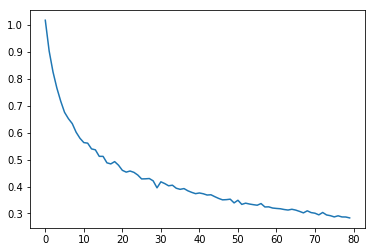

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(pred.history['loss'])


In [36]:
# evaluate the model
scores = irisModel.evaluate(X, y)
scores

150/150 [==============================] - 0s 209us/step


0.300970622698466

In [37]:
y_predict=irisModel.predict_classes(Xtest)
# evaluate the model
scores = irisModel.evaluate(X, y)
scores

150/150 [==============================] - 0s 52us/step


0.300970622698466

### Save the Model

In [0]:
irisModel.save("iris_model.dump")

### Build and Train a Deep Neural network with 2 hidden layer  - Optional - For Practice

Does it perform better than Linear Classifier? What could be the reason for difference in performance?